In [1]:
import pandas as pd

In [9]:
mfrc_annotator = pd.read_csv("./data_nlpforsocialinteractions/MFRC_annotator_based_nlpforsocialinteractions.csv", delimiter='\t')
df = pd.read_csv("./data_nlpforsocialinteractions/MFRC_nlpforsocialinteractions.csv", delimiter='\t')

In [10]:
df

,ID,text,Equality,Care,Non-Moral,Authority,Thin Morality,Loyalty,Proportionality,Purity
0,0,"Dr. Robert Jay Lifton, distinguished professo...",0,0,1,1,1,0,0,0
1,1,If you prefer not to click on Daily Mail sour...,0,0,3,0,0,0,0,0
2,2,&gt;Ben Judah details Emmanuel Macron's nasce...,0,0,0,2,0,0,1,0
3,3,"&gt;Ergo, he supports Macron but doesn't want...",0,0,1,0,1,1,0,0
4,4,&gt;He looks exactly the same in Richie Rich ...,0,0,2,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...
17452,17452,Take this poor bitch's gold! I CAN'T STOP LAU...,0,0,3,0,0,0,0,0
17453,17453,"republicans response to Cohen, This guys a fe...",0,0,2,1,0,0,0,0
17454,17454,"yes, full name is Lucy Clawless: Princess War...",0,0,3,0,0,0,0,0
17455,17455,No but seriously now. It doesn't take a geniu...,0,0,2,0,0,1,0,0


## RQ2: Selecting stratified sample of 1000 rows for persona

In [20]:
def get_stratified_sample(df, targets):
    final_sample = pd.DataFrame()
    remaining_df = df.copy()

    for foundation, count in targets.items():
        pool = remaining_df[remaining_df[foundation] > 0]
        
        sample_size = min(len(pool), count)
        sampled_rows = pool.sample(n=sample_size, random_state=42)
        
        final_sample = pd.concat([final_sample, sampled_rows])
        remaining_df = remaining_df.drop(sampled_rows.index)
        
    return final_sample

# target counts for each moral foundation category
sampling_plan = {
    'Care': 300,
    'Authority': 300,
    'Purity': 300,
    'Thin Morality': 100
}

sampled_df_1000 = get_stratified_sample(df, sampling_plan)

In [26]:
sampled_df_1000

,ID,text,Equality,Care,Non-Moral,Authority,Thin Morality,Loyalty,Proportionality,Purity
2130,2130,"As some who voted to leave the EU, I think its quite insulting to compare Brexit to this. Marine Le Pen is a political extremist. To even compare her, even to people like Farage and Trump is very dishonest. We voted to ensure that the immigration we get is of a high standard and restore parliamentary sovereignty. Established politicians like Boris, IDS, Gove supported it. Le Pen wants to seal off her borders completely, impose dress codes in public and restrict the freedom of native minority groups (equivalent of scots and welsh in Britain) as well as foreign origin minorities.",3,1,0,0,0,1,1,0
8006,8006,It's not the minorities that are more violent but other people's reactions.,1,1,1,0,0,0,1,0
104,104,"""I hate people who argue like this"" Glad to know I have earned your hate. Regardless, I am still unclear why he needs the approval of the person who did a crappy thing to undo the crappy thing.",0,1,0,0,2,0,0,0
10821,10821,Our voting system makes what Macron did impossible without the utter death of one of the existing parties IMO,0,1,2,0,0,0,0,0
679,679,"&gt; What do they want now? They want nothing, everyone else is whining and complaining that someone who they call a bolshevik and always shown hatred and despise to won't bend over and encourage everyone to vote for a banker and a supporter of capitalist extremism. He already said Le Pen is a fascist and that he is an anti-fascist but somehow even if you are not a capitalist you must show support to a far-capitalist plan.",2,1,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
2214,2214,BABY BOOMERS: Our parents died fighting fascism in WWII so their kids would have the freedom to destroy America.,0,0,0,1,1,1,0,0
8005,8005,"It's not that simple. Diplomacy with these fucks requires compromise, this is one made often. Personally, I applaud Le Pen for this stand despite hating pretty much everything about her politically.",0,0,1,0,2,0,0,0
13095,13095,"The wiki doesn't specify the amount, but since they literally use ""buying a bag of marijuana"" I have to assume it wasn't any actual weight.",0,0,2,0,1,0,0,0
153,153,"""President Francois Hollande said the situation was under control but the ""threat of terrorism is here to stay""."" What confidence and security the French people must feel in this guy.",0,0,1,1,1,0,0,0


In [27]:
sampled_df_1000.to_csv("./data_nlpforsocialinteractions/MFRC_nlpforsocialinteractions_sampled_1000.csv", index=False, sep='\t')

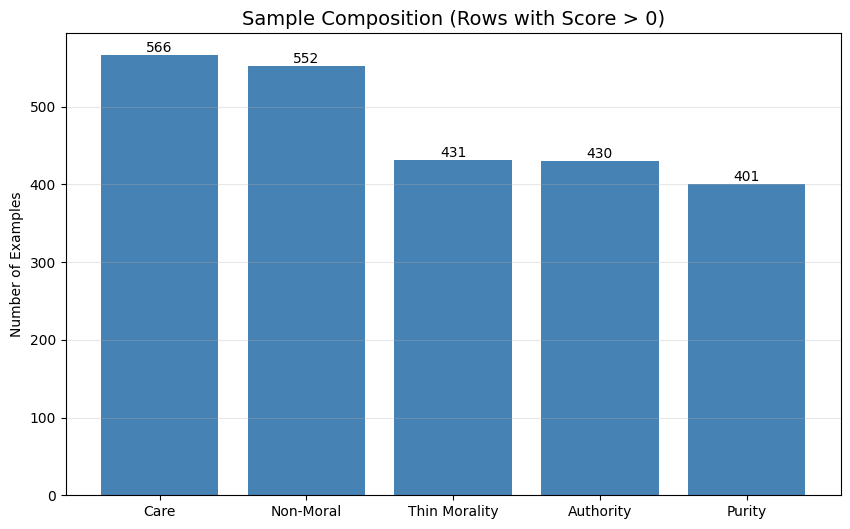

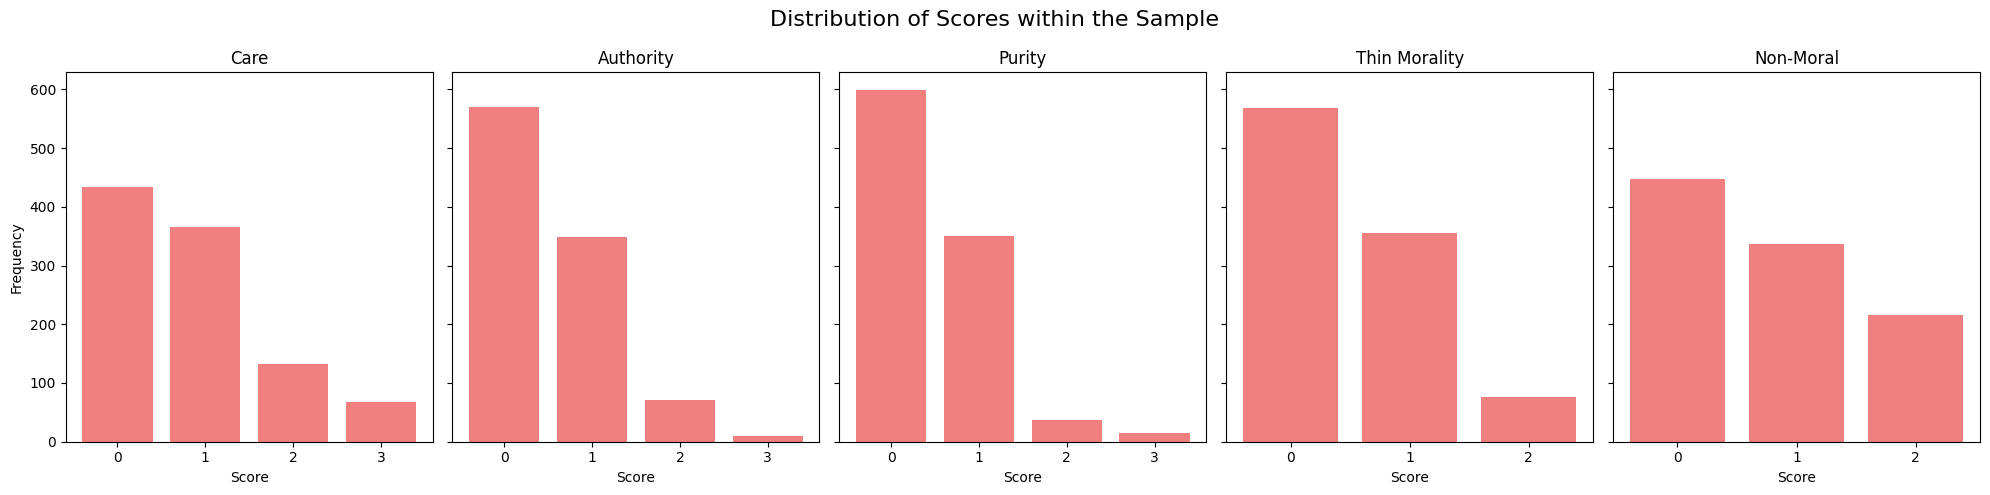

In [25]:
import matplotlib.pyplot as plt

target_cols = ['Care', 'Authority', 'Purity', 'Thin Morality', 'Non-Moral']

# 2. Plot the "Presence" (How many rows have this foundation?)
# This confirms if your 300/300/300/100 split worked
plt.figure(figsize=(10, 6))
presence_counts = (sampled_df_1000[target_cols] > 0).sum().sort_values(ascending=False)
bars = plt.bar(presence_counts.index, presence_counts.values, color='steelblue')

plt.title('Sample Composition (Rows with Score > 0)', fontsize=14)
plt.ylabel('Number of Examples')
plt.grid(axis='y', alpha=0.3)

# Add number labels on top of bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
             int(bar.get_height()), ha='center', va='bottom')

plt.show()

# 3. Plot the Score Distributions (Histograms)
fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)
for i, col in enumerate(target_cols):
    val_counts = sampled_df_1000[col].value_counts().sort_index()
    axes[i].bar(val_counts.index.astype(str), val_counts.values, color='lightcoral')
    axes[i].set_title(col)
    axes[i].set_xlabel('Score')
    if i == 0: axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Scores within the Sample', fontsize=16)
plt.tight_layout()
plt.show()

## RQ3: Selecting most confusing rows for manual annotation
at least 1 for purity, care, authority, thin morality for manual annotation

In [15]:
all = df[(df['Purity'] > 0) & (df['Care'] > 0) & (df['Authority'] > 0) & (df['Thin Morality'] > 0)]

In [17]:
pd.set_option('display.max_colwidth', None)

In [19]:
all.to_csv("./data_nlpforsocialinteractions/MFRC_nlpforsocialinteractions_filtered.csv", index=False, sep='\t')